---
## Cell 1 — Imports and reproducibility

In [ ]:
import os
import re
import pickle
from collections import OrderedDict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

RANDOM_SEED = 18
np.random.seed(RANDOM_SEED)
print('All imports OK.')

All imports OK.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Cell 2 — AmplitudeTokenizer

| Step | What it does | Why |
|------|-------------|-----|
| Remove whitespace | Collapses all spacing | Raw strings have inconsistent spacing |
| Protect `p_N`/`s_N` | Temp-rename to `MOMENTUM_N` | These are physical labels, not arbitrary indices |
| Separate `\\` and `%` | Add spaces | Greek tensor indices are compound symbols |
| Generic index normalizer | `word_12345` -> `INDEX_N` | Prevents index blowup in vocabulary |
| Particle spinor normalizer | `i_N`, `j_N`, `k_N`, `l_N` -> `PINDEX_N` | Same reason |
| Operator spacing | Each math operator gets surrounding spaces | Operators become independent tokens |
| `(*) -> CONJ` | Complex conjugate becomes a readable atom | Cleaner vocabulary |
| Split on whitespace | Final tokenization | All structure already encoded into atoms |

In [ ]:
class AmplitudeTokenizer:

    def __init__(self, index_pool_size=1000, special_symbols=None, to_replace=True):
        self.index_pool_size = index_pool_size
        self.to_replace = to_replace

        if special_symbols is None:
            self.special_symbols = [
                '<PAD>',    # 0 - padding
                '<UNK>',    # 1 - unknown token
                '<BOS>',    # 2 - begin of sequence
                '<EOS>',    # 3 - end of sequence
                '<SEP>',    # 4 - separator
                '<TERM0>',  # 5 - term boundary
                '<TERM1>',  # 6 - term boundary variant
            ]
        else:
            self.special_symbols = special_symbols

        # Pre-generate name pools so normalization is O(1) lookup
        self.index_pool = [f'INDEX_{i}' for i in range(index_pool_size)]
        self.particle_index_pool = [f'PINDEX_{i}' for i in range(index_pool_size)]

        # Matches particle spinor labels: i_12345, j_6789, k_0, l_999
        self.pattern_particle = re.compile(
            r'(?P<prefix>\b(?:\w+_)?)?(?P<target>[ijkl]_\d+\b)'
        )

        # Matches generic word_NUMBER tokens (excludes momentum p_N, s_N,
        # spinor i/j/k/l_N, and already-replaced MOMENTUM_ tokens)
        self.pattern_num_123 = re.compile(
            r'\b(?![psijkl]_)(?!MOMENTUM_)(?!\w+_\w+_)\w+_\d+\b'
        )

        self.pattern_momentum = re.compile(r'[ps]_(\d+)')

    # -------------------------------------------------------------------------
    @staticmethod
    def remove_whitespace(text):
        return re.sub(r'\s+', '', text)

    @staticmethod
    def split_expression(text):
        return re.split(r' ', text)

    # -------------------------------------------------------------------------
    def normalize_indices(self, text):

        if not self.to_replace:
            return text

        # Step 1
        text = self.remove_whitespace(text)

        # Step 2: protect momentum labels
        text = re.sub(r'p_(\d+)', r'MOMENTUM_\1', text)
        text = re.sub(r's_(\d+)', r'MOMENTUM_\1', text)

        # Step 3: space out special physics notation characters
        text = (
            text
            .replace('\\\\', '\\')
            .replace('\\', ' \\ ')
            .replace('%', ' % ')
        )

        # Step 4: generic tensor/spinor index normalization
        index_matches = list(OrderedDict.fromkeys(
            self.pattern_num_123.findall(text)
        ))

        index_iter = iter(self.index_pool)
        index_mapping = {}
        for match in index_matches:
            try:
                index_mapping[match] = next(index_iter)
            except StopIteration:
                raise RuntimeError(
                    f'INDEX pool exhausted at {self.index_pool_size}. '
                    'Increase index_pool_size.'
                )

        # Replace longest names first to avoid partial matches
        for old, new in sorted(index_mapping.items(),
                                key=lambda x: len(x[0]), reverse=True):
            text = text.replace(old, new)

        # Step 5: particle spinor index normalization
        particle_matches = list(OrderedDict.fromkeys(
            m.group('target')
            for m in sorted(
                self.pattern_particle.finditer(text),
                key=lambda m: m.start()
            )
        ))

        particle_iter = iter(self.particle_index_pool)
        particle_mapping = {}
        for match in particle_matches:
            try:
                particle_mapping[match] = next(particle_iter)
            except StopIteration:
                raise RuntimeError('PINDEX pool exhausted. Increase index_pool_size.')

        for old, new in sorted(particle_mapping.items(),
                                key=lambda x: len(x[0]), reverse=True):
            text = text.replace(old, new)

        return text

    # -------------------------------------------------------------------------
    def tokenize_amplitude(self, amplitude_text):
        if self.to_replace:
            text = self.normalize_indices(amplitude_text)
        else:
            text = amplitude_text

        text = self.remove_whitespace(text)

        # Physics-specific substitutions
        text = text.replace('(*)', ' CONJ ')
        text = text.replace('(theta_W)', '_theta_W')

        # Ensure backslash / percent are separated
        text = (
            text
            .replace('\\\\', '\\')
            .replace('\\', ' \\ ')
            .replace('%', ' % ')
        )

        # Math operators become own tokens
        for symbol in ['/', '+', '-', '*', ',', '^', '%', '}', '(', ')', '=', '[', ']']:
            text = text.replace(symbol, f' {symbol} ')

        # Split INDEX/PINDEX suffixes from preceding underscore
        text = text.replace('_PINDEX', '_ PINDEX').replace('_INDEX', '_ INDEX')

        # reg_prop is a single semantic unit
        text = text.replace('reg_prop', ' reg_prop ')

        text = re.sub(r' {2,}', ' ', text).strip()
        tokens = [t for t in self.split_expression(text) if t]
        return tokens

    # -------------------------------------------------------------------------
    def tokenize_squared(self, squared_text):
        if self.to_replace:
            text = self.normalize_indices(squared_text)
        else:
            text = squared_text

        text = self.remove_whitespace(text)
        text = text.replace('(theta_W)', '_theta_W')

        for symbol in ['/', '+', '-', '*', ',', '^', '%', '}', '(', ')', '=', '[', ']']:
            text = text.replace(symbol, f' {symbol} ')

        # Masses like m_b, m_e, m_mu, m_t -> ensure they are separate tokens
        text = re.sub(r'\bm_(\w+)\b', r' m_\1 ', text)

        # Mandelstam variables s_12, s_13, s_23 etc.
        text = re.sub(r'\bs_(\d{2,})\b', r' s_\1 ', text)

        text = text.replace('reg_prop', ' reg_prop ')
        text = re.sub(r' {2,}', ' ', text).strip()
        tokens = [t for t in self.split_expression(text) if t]
        return tokens


print('AmplitudeTokenizer defined.')

AmplitudeTokenizer defined.


---
## Cell 3 — Vocabulary class

A bidirectional token <-> index map built from the training split only
(to avoid test-set leakage). Unknown tokens at inference time map to `<UNK>`.

In [ ]:
class Vocabulary:
    def __init__(self, tokens, special_symbols,
                 pad_idx=0, unk_idx=1, bos_idx=2, eos_idx=3,
                 sep_idx=4, term_idx=None):
        if term_idx is None:
            term_idx = [5, 6]

        tokens = list(tokens)
        for special in special_symbols:
            if special in tokens:
                tokens.remove(special)

        # Special tokens first -> fixed indices
        self.token_list = special_symbols + tokens
        self.token_to_idx = {tok: idx for idx, tok in enumerate(self.token_list)}
        self.idx_to_token = {idx: tok for tok, idx in self.token_to_idx.items()}

        self.pad_idx = pad_idx
        self.unk_idx = unk_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.sep_idx = sep_idx
        self.term_idx = term_idx

        self.pad_tok = special_symbols[pad_idx]
        self.unk_tok = special_symbols[unk_idx]
        self.bos_tok = special_symbols[bos_idx]
        self.eos_tok = special_symbols[eos_idx]
        self.sep_tok = special_symbols[sep_idx]

        self.special_indices = set(
            self.token_to_idx[sym] for sym in special_symbols
        )

    def encode(self, tokens):
        """Map token list -> index list; unknown tokens map to unk_idx."""
        return [self.token_to_idx.get(tok, self.unk_idx) for tok in tokens]

    def decode(self, indices, include_special=True):
        """Map index list -> token list."""
        if include_special:
            return [self.idx_to_token.get(idx, self.unk_tok) for idx in indices]
        return [
            self.idx_to_token.get(idx, self.unk_tok)
            for idx in indices
            if idx not in self.special_indices or idx == self.sep_idx
        ]

    def __len__(self):
        return len(self.token_list)

    def __getitem__(self, item):
        if isinstance(item, int):
            return self.idx_to_token.get(item, self.unk_tok)
        return self.token_to_idx.get(item, self.unk_idx)

    def tokens(self):
        return self.token_list


print('Vocabulary class defined.')

Vocabulary class defined.


---
## Cell 4 — Data loading

Each raw `.txt` file has rows formatted as:
```
Interaction : Feynman_diagram : amplitude : squared_amplitude
```
We split on ` : ` and keep all four fields.

> **Set `DATA_DIR`** to the folder containing your 17 `.txt` files.  
> Files whose names contain `QED` are treated as QED; those containing `QCD` as QCD.

In [ ]:
DATA_DIR = '/content/drive/MyDrive/Datasets/SYMBA/SYMBA - Test Data'   # <-- CHANGE THIS to your actual folder
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs('./data/processed', exist_ok=True)
print(f'Data directory: {os.path.abspath(DATA_DIR)}')

Data directory: /content/drive/MyDrive/Datasets/SYMBA/SYMBA - Test Data


In [ ]:
all_files = sorted(f for f in os.listdir(DATA_DIR) if f.endswith('.txt'))
print(f'Found {len(all_files)} .txt files:')
for f in all_files:
    print(f'  {f}')

qed_files = [f for f in all_files if 'QED' in f.upper()]
qcd_files = [f for f in all_files if 'QCD' in f.upper()]
print(f'\n  QED files: {len(qed_files)}')
print(f'  QCD files: {len(qcd_files)}')

Found 17 .txt files:
  QCD-2-to-2-diag-TreeLevel-0.txt
  QCD-2-to-2-diag-TreeLevel-1.txt
  QCD-2-to-2-diag-TreeLevel-2.txt
  QCD-2-to-2-diag-TreeLevel-3.txt
  QCD-2-to-2-diag-TreeLevel-4.txt
  QCD-2-to-2-diag-TreeLevel-5.txt
  QCD-2-to-2-diag-TreeLevel-6.txt
  QED-2-to-2-diag-TreeLevel-0.txt
  QED-2-to-2-diag-TreeLevel-1.txt
  QED-2-to-2-diag-TreeLevel-2.txt
  QED-2-to-2-diag-TreeLevel-3.txt
  QED-2-to-2-diag-TreeLevel-4.txt
  QED-2-to-2-diag-TreeLevel-5.txt
  QED-2-to-2-diag-TreeLevel-6.txt
  QED-2-to-2-diag-TreeLevel-7.txt
  QED-2-to-2-diag-TreeLevel-8.txt
  QED-2-to-2-diag-TreeLevel-9.txt

  QED files: 10
  QCD files: 7


In [ ]:
def load_raw_file(filepath):
    records = []
    filename = os.path.basename(filepath)

    with open(filepath, 'r', encoding='utf-8') as fh:
        for line_num, raw_line in enumerate(fh, start=1):
            line = raw_line.strip()
            if not line:
                continue

            parts = line.split(' : ')
            if len(parts) < 4:
                print(f'[WARN] {filename}:{line_num} only {len(parts)} parts, skipping.')
                continue

            interaction       = parts[0].strip()
            diagram           = parts[1].strip()
            amplitude         = parts[2].strip()
            squared_amplitude = ' : '.join(parts[3:]).strip()

            records.append({
                'interaction':       interaction,
                'diagram':           diagram,
                'amplitude':         amplitude,
                'squared_amplitude': squared_amplitude,
                'source_file':       filename,
                'line_num':          line_num,
            })

    return pd.DataFrame(records)


def load_all_files(file_list, data_dir, physics_model):
    frames = []
    for fname in tqdm(file_list, desc=f'Loading {physics_model}'):
        fpath = os.path.join(data_dir, fname)
        df = load_raw_file(fpath)
        df['model'] = physics_model
        frames.append(df)
        print(f'  {fname}: {len(df):,} rows')

    if not frames:
        return pd.DataFrame()
    combined = pd.concat(frames, ignore_index=True)
    print(f'  -> {physics_model} total: {len(combined):,} rows')
    return combined


print('Helper functions defined.')

Helper functions defined.


In [ ]:
qed_data = load_all_files(qed_files, DATA_DIR, 'QED')
qcd_data = load_all_files(qcd_files, DATA_DIR, 'QCD')

all_data = pd.concat([qed_data, qcd_data], ignore_index=True)

print(f'\nTotal rows loaded : {len(all_data):,}')
print(f'  QED : {len(qed_data):,}')
print(f'  QCD : {len(qcd_data):,}')
print(f'\nMissing values:')
print(all_data.isnull().sum())
all_data.head(3)

Loading QED:  10%|█         | 1/10 [00:00<00:03,  2.32it/s]

  QED-2-to-2-diag-TreeLevel-0.txt: 54 rows


Loading QED:  20%|██        | 2/10 [00:00<00:02,  2.97it/s]

  QED-2-to-2-diag-TreeLevel-1.txt: 50 rows


Loading QED:  30%|███       | 3/10 [00:00<00:02,  3.29it/s]

...

Loading QCD:  86%|████████▌ | 6/7 [00:01<00:00,  3.13it/s]

  QCD-2-to-2-diag-TreeLevel-5.txt: 26 rows


Loading QCD: 100%|██████████| 7/7 [00:02<00:00,  3.22it/s]

  QCD-2-to-2-diag-TreeLevel-6.txt: 18 rows
  -> QCD total: 234 rows

Total rows loaded : 594
  QED : 360
  QCD : 234

Missing values:
interaction          0
diagram              0
amplitude            0
squared_amplitude    0
source_file          0
line_num             0
model                0
dtype: int64


,interaction,diagram,amplitude,squared_amplitude,source_file,line_num,model
0,Interaction: e_eps_60(X)^(*) AntiPart e_eta_...,"Vertex V_1:mu(X_3), AntiPart mu(X_4), OffShel...","-1/2*i*e^2*gamma_{+%\sigma_249,%gam_165,%del_1...",1/4*e^4*(16*m_e^2*m_mu^2 + 8*m_mu^2*s_12 + 8*s...,QED-2-to-2-diag-TreeLevel-0.txt,1,QED
1,Interaction: e_gam_265(X)^(*) AntiPart e_del...,"Vertex V_1:t(X_3), AntiPart t(X_4), OffShell ...","-1/2*i*e^2*gamma_{+%\tau_428,%gam_262,%eps_110...",1/4*e^4*(16*m_e^2*m_t^2 + 8*m_t^2*s_12 + 8*s_1...,QED-2-to-2-diag-TreeLevel-0.txt,2,QED
2,Interaction: e_gam_344(X)^(*) AntiPart e_del...,"Vertex V_1:u(X_3), AntiPart u(X_4), OffShell ...","1/3*i*e^2*gamma_{+%\sigma_622,%eta_238,%beta_1...",1/9*e^4*(16*m_e^2*m_u^2 + 8*m_u^2*s_12 + 8*s_1...,QED-2-to-2-diag-TreeLevel-0.txt,3,QED


---
## Cell 5 — Tokenizer smoke test

Manually inspect a QED and a QCD example to verify every physics character is preserved.

In [ ]:
SPECIAL_SYMBOLS = ['<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>', '<TERM0>', '<TERM1>']

tokenizer = AmplitudeTokenizer(
    index_pool_size=1000,
    special_symbols=SPECIAL_SYMBOLS,
    to_replace=True,
)

print('Tokenizer initialized.')
print(f'  Index pool size : {tokenizer.index_pool_size}')
print(f'  Replace indices : {tokenizer.to_replace}')

Tokenizer initialized.
  Index pool size : 1000
  Replace indices : True


In [ ]:
def inspect_example(row, label=''):
    amp = row['amplitude']
    sq  = row['squared_amplitude']

    norm_amp   = tokenizer.normalize_indices(amp)
    norm_sq    = tokenizer.normalize_indices(sq)
    amp_tokens = tokenizer.tokenize_amplitude(amp)
    sq_tokens  = tokenizer.tokenize_squared(sq)

    print(f'\n{"="*70}')
    print(f'EXAMPLE: {label}')
    print(f'  Source file : {row["source_file"]}  line {row["line_num"]}')
    print(f'  Interaction : {row["interaction"][:80]}...')
    print(f'\n--- AMPLITUDE (raw, first 150 chars) ---')
    print(amp[:150])
    print(f'\n--- AMPLITUDE (normalized, first 150 chars) ---')
    print(norm_amp[:150])
    print(f'\n--- AMPLITUDE TOKENS ({len(amp_tokens)} tokens) ---')
    print(amp_tokens)
    print(f'\n--- SQUARED AMP (raw) ---')
    print(sq)
    print(f'\n--- SQUARED AMP (normalized) ---')
    print(norm_sq)
    print(f'\n--- SQUARED AMP TOKENS ({len(sq_tokens)} tokens) ---')
    print(sq_tokens)


if len(qed_data) > 0:
    inspect_example(qed_data.iloc[0], label='QED row 0')

if len(qcd_data) > 0:
    inspect_example(qcd_data.iloc[0], label='QCD row 0')


EXAMPLE: QED row 0
  Source file : QED-2-to-2-diag-TreeLevel-0.txt  line 1
  Interaction : Interaction:  e_eps_60(X)^(*)  AntiPart e_eta_138(X)  to  mu_alpha_141(X)  AntiP...

--- AMPLITUDE (raw, first 150 chars) ---
-1/2*i*e^2*gamma_{+%\sigma_249,%gam_165,%del_165}*gamma_{%\sigma_249,%gam_166,%del_166}*e_{k_43,%del_166}(p_1)_u*e_{l_43,%gam_166}(p_2)_v^(*)*mu_{i_45

--- AMPLITUDE (normalized, first 150 chars) ---
-1/2*i*e^2*gamma_{+ %  \ INDEX_0, % INDEX_1, % INDEX_2}*gamma_{ %  \ INDEX_0, % INDEX_3, % INDEX_4}*e_{PINDEX_0, % INDEX_4}(MOMENTUM_1)_u*e_{PINDEX_1,

--- AMPLITUDE TOKENS (93 tokens) ---
['-', '1', '/', '2', '*', 'i', '*', 'e', '^', '2', '*', 'gamma_{', '+', '%', '\\', 'INDEX_0', ',', '%', 'INDEX_1', ',', '%', 'INDEX_2', '}', '*', 'gamma_{', '%', '\\', 'INDEX_0', ',', '%', 'INDEX_3', ',', '%', 'INDEX_4', '}', '*', 'e_{PINDEX_0', ',', '%', 'INDEX_4', '}', '(', 'MOMENTUM_1', ')', '_u', '*', 'e_{PINDEX_1', ',', '%', 'INDEX_3', '}', '(', 'MOMENTUM_2', ')', '_v', '^', 'CONJ', '*

---
## Cell 6 — 80 / 10 / 10 train / val / test split

**Why split before building the vocabulary?**  
The vocabulary must be built from the training set only. Fitting on val/test tokens would leak information about the held-out distributions.

The split is performed per-model (QED / QCD) so each model gets balanced splits.

In [ ]:
def three_way_split(df, train_frac=0.80, val_frac=0.10, random_state=RANDOM_SEED):
    val_of_remaining = val_frac / (1.0 - train_frac)  # 0.50 of the 20%

    train_df, temp_df = train_test_split(
        df, train_size=train_frac, random_state=random_state, shuffle=True
    )
    val_df, test_df = train_test_split(
        temp_df, train_size=val_of_remaining, random_state=random_state, shuffle=True
    )
    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


qed_train, qed_val, qed_test = three_way_split(qed_data)
print(f'QED  -> train: {len(qed_train):,}  val: {len(qed_val):,}  test: {len(qed_test):,}')

qcd_train, qcd_val, qcd_test = three_way_split(qcd_data)
print(f'QCD  -> train: {len(qcd_train):,}  val: {len(qcd_val):,}  test: {len(qcd_test):,}')

all_train = pd.concat([qed_train, qcd_train], ignore_index=True)
all_val   = pd.concat([qed_val,   qcd_val],   ignore_index=True)
all_test  = pd.concat([qed_test,  qcd_test],  ignore_index=True)
print(f'\nCombined -> train: {len(all_train):,}  val: {len(all_val):,}  test: {len(all_test):,}')

QED  -> train: 288  val: 36  test: 36
QCD  -> train: 187  val: 23  test: 24

Combined -> train: 475  val: 59  test: 60


---
## Cell 7 — Tokenize all rows

Token lists are stored as new columns `amp_tokens` and `sq_tokens`.

In [ ]:
def apply_tokenization(df, tokenizer, desc=''):
    df = df.copy()
    amp_tokens_list, sq_tokens_list = [], []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        amp_tokens_list.append(tokenizer.tokenize_amplitude(row['amplitude']))
        sq_tokens_list.append(tokenizer.tokenize_squared(row['squared_amplitude']))

    df['amp_tokens'] = amp_tokens_list
    df['sq_tokens']  = sq_tokens_list
    df['amp_len']    = df['amp_tokens'].apply(len)
    df['sq_len']     = df['sq_tokens'].apply(len)
    return df


qed_train = apply_tokenization(qed_train, tokenizer, 'QED train')
qed_val   = apply_tokenization(qed_val,   tokenizer, 'QED val  ')
qed_test  = apply_tokenization(qed_test,  tokenizer, 'QED test ')

qcd_train = apply_tokenization(qcd_train, tokenizer, 'QCD train')
qcd_val   = apply_tokenization(qcd_val,   tokenizer, 'QCD val  ')
qcd_test  = apply_tokenization(qcd_test,  tokenizer, 'QCD test ')

print('\nAll rows tokenized.')

QCD test : 100%|██████████| 24/24 [00:00<00:00, 717.96it/s]


All rows tokenized.


---
## Cell 8 — Vocabulary construction

Vocabularies are built **per model** (QED vs QCD) and **per role** (source / target).

Why separate source and target vocabularies?
- The **source** (amplitude) contains tensor index tokens (`INDEX_N`, `PINDEX_N`),
  wavefunction labels (`gamma_{...}`), etc. that never appear in the target.
- The **target** (squared amplitude) is a compact polynomial with only Mandelstam
  variables, masses, and coupling constants.
- Keeping them separate reduces target vocabulary size and prevents the decoder
  from hallucinating impossible tokens.

In [ ]:
def build_vocab(train_df, token_col, special_symbols):
    counter = Counter()
    for token_list in train_df[token_col]:
        counter.update(token_list)

    # Sort alphabetically for determinism
    sorted_tokens = sorted(counter.keys())
    return Vocabulary(sorted_tokens, special_symbols)


qed_src_vocab = build_vocab(qed_train, 'amp_tokens', SPECIAL_SYMBOLS)
qed_tgt_vocab = build_vocab(qed_train, 'sq_tokens',  SPECIAL_SYMBOLS)
print(f'QED source vocab size : {len(qed_src_vocab):,}')
print(f'QED target vocab size : {len(qed_tgt_vocab):,}')

qcd_src_vocab = build_vocab(qcd_train, 'amp_tokens', SPECIAL_SYMBOLS)
qcd_tgt_vocab = build_vocab(qcd_train, 'sq_tokens',  SPECIAL_SYMBOLS)
print(f'\nQCD source vocab size : {len(qcd_src_vocab):,}')
print(f'QCD target vocab size : {len(qcd_tgt_vocab):,}')

QED source vocab size : 97
QED target vocab size : 43

QCD source vocab size : 179
QCD target vocab size : 67


---
## Cell 9 — Encode tokens -> integer IDs

Each sequence is wrapped with `<BOS>` and `<EOS>` as is standard for seq2seq.

In [ ]:
def encode_split(df, src_vocab, tgt_vocab):
    """Add integer-encoded columns amp_ids and sq_ids (BOS-wrapped)."""
    df = df.copy()
    df['amp_ids'] = df['amp_tokens'].apply(
        lambda toks: [src_vocab.bos_idx] + src_vocab.encode(toks) + [src_vocab.eos_idx]
    )
    df['sq_ids'] = df['sq_tokens'].apply(
        lambda toks: [tgt_vocab.bos_idx] + tgt_vocab.encode(toks) + [tgt_vocab.eos_idx]
    )
    return df


qed_train = encode_split(qed_train, qed_src_vocab, qed_tgt_vocab)
qed_val   = encode_split(qed_val,   qed_src_vocab, qed_tgt_vocab)
qed_test  = encode_split(qed_test,  qed_src_vocab, qed_tgt_vocab)

qcd_train = encode_split(qcd_train, qcd_src_vocab, qcd_tgt_vocab)
qcd_val   = encode_split(qcd_val,   qcd_src_vocab, qcd_tgt_vocab)
qcd_test  = encode_split(qcd_test,  qcd_src_vocab, qcd_tgt_vocab)

# Decode sanity check
print('\n-- QED DECODE SANITY CHECK --')
row = qed_train.iloc[0]
decoded_sq = qed_tgt_vocab.decode(row['sq_ids'], include_special=False)
print(f'Original  : {row["squared_amplitude"]}')
print(f'Decoded   : {" ".join(decoded_sq)}')
print('Encoding OK.')


-- QED DECODE SANITY CHECK --
Original  : 32/81*e^4*s_14*s_34*(s_23 + -1/2*reg_prop)^(-2) + -64/81*i*e^2*(i*e^2*m_tt^2*(m_tt^2 + -1/2*s_13)/(s_23 + -1/2*reg_prop) + -1/16*i*e^2*m_tt^2*(16*s_14 + (-8)*s_34)/(s_23 + -1/2*reg_prop))/(s_23 + -1/2*reg_prop)
Decoded   : 32 / 81 * e ^ 4 * MOMENTUM_14 * MOMENTUM_34 * ( MOMENTUM_23 + - 1 / 2 * reg_prop ) ^ ( - 2 ) + - 64 / 81 * i * e ^ 2 * ( i * e ^ 2 * m_tt ^ 2 * ( m_tt ^ 2 + - 1 / 2 * MOMENTUM_13 ) / ( MOMENTUM_23 + - 1 / 2 * reg_prop ) + - 1 / 16 * i * e ^ 2 * m_tt ^ 2 * ( 16 * MOMENTUM_14 + ( - 8 ) * MOMENTUM_34 ) / ( MOMENTUM_23 + - 1 / 2 * reg_prop ) ) / ( MOMENTUM_23 + - 1 / 2 * reg_prop )
Encoding OK.


---
## Cell 10 — Sequence length statistics & visualisation

In [ ]:
def length_stats(df, model_name):
    print(f'\n{model_name} length statistics (training split):')
    for col, label in [('amp_len', 'Amplitude'), ('sq_len', 'Squared amp')]:
        s = df[col]
        print(f'  {label:15s} -- mean={s.mean():.1f}  median={s.median():.0f}  '
              f'max={s.max()}  95th={s.quantile(0.95):.0f}')


length_stats(qed_train, 'QED')
length_stats(qcd_train, 'QCD')


QED length statistics (training split):
  Amplitude       -- mean=127.3  median=94  max=183  95th=179
  Squared amp     -- mean=90.9  median=73  max=124  95th=124

QCD length statistics (training split):
  Amplitude       -- mean=464.4  median=241  max=1890  95th=1472
  Squared amp     -- mean=432.6  median=245  max=1622  95th=1622


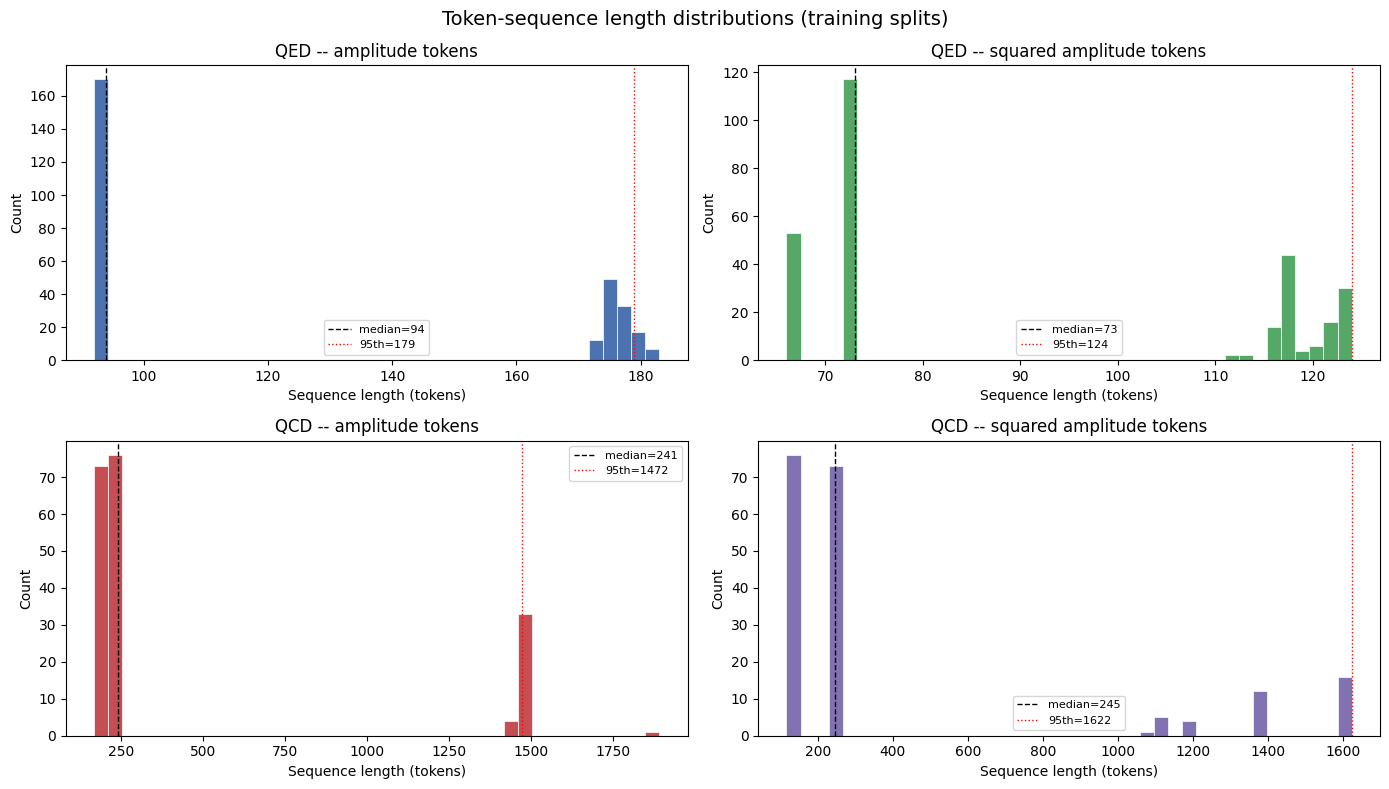

Figure saved.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Token-sequence length distributions (training splits)', fontsize=14)

plot_configs = [
    (qed_train, 'amp_len', 'QED -- amplitude tokens',        axes[0, 0], '#4C72B0'),
    (qed_train, 'sq_len',  'QED -- squared amplitude tokens', axes[0, 1], '#55A868'),
    (qcd_train, 'amp_len', 'QCD -- amplitude tokens',        axes[1, 0], '#C44E52'),
    (qcd_train, 'sq_len',  'QCD -- squared amplitude tokens', axes[1, 1], '#8172B2'),
]

for df, col, title, ax, color in plot_configs:
    ax.hist(df[col], bins=40, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].median(), color='black', linestyle='--', linewidth=1,
               label=f'median={df[col].median():.0f}')
    ax.axvline(df[col].quantile(0.95), color='red', linestyle=':', linewidth=1,
               label=f'95th={df[col].quantile(0.95):.0f}')
    ax.set_title(title)
    ax.set_xlabel('Sequence length (tokens)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('./data/processed/length_distributions.png', dpi=150)
plt.show()
print('Figure saved.')

---
## Cell 11 — Vocabulary inspection

Spot-check that key physics tokens are present.

In [ ]:
def check_tokens_in_vocab(vocab, tokens_to_check, vocab_name):
    print(f'\n-- {vocab_name} (size={len(vocab)}) -- token presence check --')
    for tok in tokens_to_check:
        idx = vocab[tok]
        status = 'OK' if idx != vocab.unk_idx else 'MISSING (UNK)'
        print(f'  {tok:20s} -> idx {idx:5d}  {status}')


EXPECTED_SRC = [
    'gamma', 'CONJ', 'reg_prop',
    'INDEX_0', 'PINDEX_0',
    '%', '/', '*', '+', '-', '^', '(', ')', '{', '}', ',',
]
EXPECTED_TGT = [
    'e', 'm_b', 'm_e', 's_12', 's_34', 'reg_prop',
    '/', '*', '+', '-', '^', '(', ')',
]

check_tokens_in_vocab(qed_src_vocab, EXPECTED_SRC, 'QED source vocab')
check_tokens_in_vocab(qed_tgt_vocab, EXPECTED_TGT, 'QED target vocab')

print('\nFirst 30 tokens in QED source vocab (after specials):')
print(qed_src_vocab.tokens()[len(SPECIAL_SYMBOLS):len(SPECIAL_SYMBOLS)+30])

print('\nFirst 30 tokens in QED target vocab (after specials):')
print(qed_tgt_vocab.tokens()[len(SPECIAL_SYMBOLS):len(SPECIAL_SYMBOLS)+30])


-- QED source vocab (size=97) -- token presence check --
  gamma                -> idx     1  MISSING (UNK)
  CONJ                 -> idx    24  OK
  reg_prop             -> idx    81  OK
  INDEX_0              -> idx    25  OK
  PINDEX_0             -> idx     1  MISSING (UNK)
  %                    -> idx     7  OK
  /                    -> idx    14  OK
  *                    -> idx    10  OK
  +                    -> idx    11  OK
  -                    -> idx    13  OK
  ^                    -> idx    46  OK
  (                    -> idx     8  OK
  )                    -> idx     9  OK
  {                    -> idx     1  MISSING (UNK)
  }                    -> idx    96  OK
  ,                    -> idx    12  OK

-- QED target vocab (size=43) -- token presence check --
  e                    -> idx    31  OK
  m_b                  -> idx    33  OK
  m_e                  -> idx    36  OK
  s_12                 -> idx     1  MISSING (UNK)
  s_34                 -> idx     1  MIS

---
## Cell 12 — Save all processed data to disk

In [ ]:
processed_data = {
    'qed': {
        'train':     qed_train.to_dict('records'),
        'val':       qed_val.to_dict('records'),
        'test':      qed_test.to_dict('records'),
        'src_vocab': qed_src_vocab,
        'tgt_vocab': qed_tgt_vocab,
    },
    'qcd': {
        'train':     qcd_train.to_dict('records'),
        'val':       qcd_val.to_dict('records'),
        'test':      qcd_test.to_dict('records'),
        'src_vocab': qcd_src_vocab,
        'tgt_vocab': qcd_tgt_vocab,
    },
    'tokenizer': tokenizer,
    'metadata': {
        'index_pool_size':    tokenizer.index_pool_size,
        'special_symbols':    SPECIAL_SYMBOLS,
        'random_seed':        RANDOM_SEED,
        'total_samples':      len(all_data),
        'qed_samples':        len(qed_data),
        'qcd_samples':        len(qcd_data),
        'qed_src_vocab_size': len(qed_src_vocab),
        'qed_tgt_vocab_size': len(qed_tgt_vocab),
        'qcd_src_vocab_size': len(qcd_src_vocab),
        'qcd_tgt_vocab_size': len(qcd_tgt_vocab),
        'split': '80/10/10',
    },
}

OUT_PATH = './data/processed/processed_data.pkl'
with open(OUT_PATH, 'wb') as fh:
    pickle.dump(processed_data, fh)

print(f'Saved to {OUT_PATH}')
print('\nMetadata summary:')
for k, v in processed_data['metadata'].items():
    print(f'  {k:25s}: {v}')

Saved to ./data/processed/processed_data.pkl

Metadata summary:
  index_pool_size          : 1000
  special_symbols          : ['<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>', '<TERM0>', '<TERM1>']
  random_seed              : 18
  total_samples            : 594
  qed_samples              : 360
  qcd_samples              : 234
  qed_src_vocab_size       : 97
  qed_tgt_vocab_size       : 43
  qcd_src_vocab_size       : 179
  qcd_tgt_vocab_size       : 67
  split                    : 80/10/10


---
## Cell 13 — Full tokenization trace (step-by-step walkthrough)

Run this cell to see every intermediate transformation for one example.

In [ ]:
def trace_tokenization(raw_text, kind='amplitude'):
    t = tokenizer
    SEP = '-' * 70

    print(SEP)
    print(f'TRACE: {kind.upper()} TOKENIZATION')
    print(SEP)

    # Step 0: raw input
    print('\n[0] RAW INPUT')
    print(raw_text[:200])

    # Step 1: remove whitespace
    s1 = t.remove_whitespace(raw_text)
    print('\n[1] AFTER remove_whitespace')
    print(s1[:200])

    # Step 2: protect momentum labels
    s2 = re.sub(r'p_(\d+)', r'MOMENTUM_\1', s1)
    s2 = re.sub(r's_(\d+)', r'MOMENTUM_\1', s2)
    print('\n[2] AFTER protecting p_N / s_N -> MOMENTUM_N')
    print(s2[:200])

    # Step 3: space backslash and percent
    s3 = s2.replace('\\\\', '\\').replace('\\', ' \\ ').replace('%', ' % ')
    print('\n[3] AFTER spacing backslash and percent')
    print(s3[:200])

    # Step 4a: find generic word_NUM tokens
    index_matches = list(OrderedDict.fromkeys(t.pattern_num_123.findall(s3)))
    print(f'\n[4a] Generic word_NUM tokens found ({len(index_matches)}):')
    print(index_matches[:20], '...' if len(index_matches) > 20 else '')

    index_iter = iter(t.index_pool)
    index_mapping = {}
    for m in index_matches:
        index_mapping[m] = next(index_iter)

    s4 = s3
    for old, new in sorted(index_mapping.items(), key=lambda x: len(x[0]), reverse=True):
        s4 = s4.replace(old, new)

    print('\n[4b] AFTER generic index normalization')
    print(s4[:200])

    # Step 5a: find spinor labels
    particle_matches = list(OrderedDict.fromkeys(
        m.group('target')
        for m in sorted(t.pattern_particle.finditer(s4), key=lambda m: m.start())
    ))
    print(f'\n[5a] Spinor labels found ({len(particle_matches)}):')
    print(particle_matches[:20])

    particle_iter = iter(t.particle_index_pool)
    particle_mapping = {}
    for m in particle_matches:
        particle_mapping[m] = next(particle_iter)

    s5 = s4
    for old, new in sorted(particle_mapping.items(), key=lambda x: len(x[0]), reverse=True):
        s5 = s5.replace(old, new)

    print('\n[5b] AFTER spinor index normalization')
    print(s5[:200])

    # Step 6: operator spacing and physics substitutions
    s6 = s5
    if kind == 'amplitude':
        s6 = s6.replace('(*)', ' CONJ ')
        s6 = s6.replace('(theta_W)', '_theta_W')
        s6 = s6.replace('_PINDEX', '_ PINDEX').replace('_INDEX', '_ INDEX')
    else:
        s6 = s6.replace('(theta_W)', '_theta_W')

    for sym in ['/', '+', '-', '*', ',', '^', '%', '}', '(', ')', '=', '[', ']']:
        s6 = s6.replace(sym, f' {sym} ')

    if kind == 'squared':
        s6 = re.sub(r'\bm_(\w+)\b', r' m_\1 ', s6)
        s6 = re.sub(r'\bs_(\d{2,})\b', r' s_\1 ', s6)

    s6 = s6.replace('reg_prop', ' reg_prop ')
    s6 = re.sub(r' {2,}', ' ', s6).strip()

    print('\n[6] AFTER operator spacing and physics substitutions')
    print(s6[:300])

    # Step 7: final split
    tokens = [tok for tok in s6.split(' ') if tok]
    print(f'\n[7] FINAL TOKENS ({len(tokens)} tokens):')
    print(tokens)
    print(SEP)
    return tokens


if len(qed_data) > 0:
    example_amp = qed_data.iloc[0]['amplitude']
    example_sq  = qed_data.iloc[0]['squared_amplitude']
    _ = trace_tokenization(example_amp, kind='amplitude')
    print()
    _ = trace_tokenization(example_sq,  kind='squared')

----------------------------------------------------------------------
TRACE: AMPLITUDE TOKENIZATION
----------------------------------------------------------------------

[0] RAW INPUT
-1/2*i*e^2*gamma_{+%\sigma_249,%gam_165,%del_165}*gamma_{%\sigma_249,%gam_166,%del_166}*e_{k_43,%del_166}(p_1)_u*e_{l_43,%gam_166}(p_2)_v^(*)*mu_{i_45,%gam_165}(p_3)_u^(*)*mu_{j_45,%del_165}(p_4)_v/(m

[1] AFTER remove_whitespace
-1/2*i*e^2*gamma_{+%\sigma_249,%gam_165,%del_165}*gamma_{%\sigma_249,%gam_166,%del_166}*e_{k_43,%del_166}(p_1)_u*e_{l_43,%gam_166}(p_2)_v^(*)*mu_{i_45,%gam_165}(p_3)_u^(*)*mu_{j_45,%del_165}(p_4)_v/(m

[2] AFTER protecting p_N / s_N -> MOMENTUM_N
-1/2*i*e^2*gamma_{+%\sigma_249,%gam_165,%del_165}*gamma_{%\sigma_249,%gam_166,%del_166}*e_{k_43,%del_166}(MOMENTUM_1)_u*e_{l_43,%gam_166}(MOMENTUM_2)_v^(*)*mu_{i_45,%gam_165}(MOMENTUM_3)_u^(*)*mu_{j_4

[3] AFTER spacing backslash and percent
-1/2*i*e^2*gamma_{+ %  \ sigma_249, % gam_165, % del_165}*gamma_{ %  \ sigma_249, % gam_166, %

---
## Summary

| Step | Description |
|------|-------------|
| 1 | Load 17 `.txt` files, split on ` : ` into 4 fields |
| 2 | Separate QED and QCD files by filename |
| 3 | `normalize_indices`: protect momenta, replace tensor/spinor indices with `INDEX_N`/`PINDEX_N` |
| 4 | `tokenize_amplitude` / `tokenize_squared`: space out operators, substitute physics symbols, split |
| 5 | 80/10/10 split per physics model, no data leakage |
| 6 | Separate source and target vocabularies from training split only |
| 7 | Encode token lists to integer IDs wrapped with BOS/EOS |
| 8 | Save everything to `processed_data.pkl` |

**Tokenization rationale:** Word-level tokenization on physics-normalized strings preserves every semantic atom as a single indivisible token. This is appropriate for symbolic regression on Feynman amplitudes where subword splitting would destroy mathematical meaning.